In [1]:
#Importing libraries and API
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token here: ")

Paste your Kaggle API token here: ··········


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
#Download RTA Dataset
import kagglehub
path = kagglehub.dataset_download("saurabhshahane/road-traffic-accidents")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'road-traffic-accidents' dataset.
Dataset downloaded to: /kaggle/input/road-traffic-accidents


In [5]:
file_path = os.path.join(path, "RTA Dataset.csv")
df = pd.read_csv(file_path)

In [6]:
#First 5 rows
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [7]:
print(df.shape)

(12316, 32)


In [9]:
#checking for missing value
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Educational_level           741
Vehicle_driver_relation     579
Driving_experience          829
Type_of_vehicle             950
Owner_of_vehicle            482
Service_year_of_vehicle    3928
Defect_of_vehicle          4427
Area_accident_occured       239
Lanes_or_Medians            385
Road_allignment             142
Types_of_Junction           887
Road_surface_type           172
Type_of_collision           155
Vehicle_movement            308
Work_of_casuality          3198
Fitness_of_casuality       2635
dtype: int64


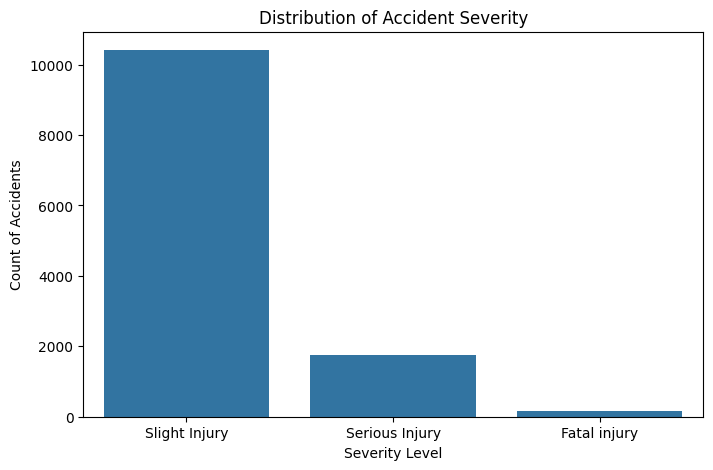

In [10]:
#Visualizing
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Accident_severity')
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Count of Accidents')
plt.show()

In [11]:
#Replace Nan with Unknown
heavy_missing_cols = ['Defect_of_vehicle', 'Service_year_of_vehicle', 'Work_of_casuality', 'Fitness_of_casuality']
for col in heavy_missing_cols:
    df[col] = df[col].fillna('Unknown')

In [12]:
#Replace with highest frequency data
other_missing_cols = [
    'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
    'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured',
    'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction',
    'Road_surface_type', 'Type_of_collision', 'Vehicle_movement'
]

for col in other_missing_cols:
    most_frequent_value = df[col].mode()[0]
    df[col] = df[col].fillna(most_frequent_value)

In [29]:
import numpy as np

df = df.replace(['na', 'Na', 'NA', 'unknown', 'Unknown'], np.nan)

df = df.fillna('Unknown')

print("Absolute total of missing values left:", df.isnull().sum().sum())

df.head(10)

Absolute total of missing values left: 0


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Moving Backward,slight injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Overtaking,slight injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Going straight,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,serious injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,slight injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,...,Going straight,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Not a Pedestrian,Overtaking,slight injury
5,14:15:00,Friday,31-50,Male,Junior high school,Unknown,5-10yr,Automobile,Owner,Unknown,...,U-Turn,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Overloading,slight injury
6,17:30:00,Wednesday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,Unknown,...,Moving Backward,Driver or rider,Female,18-30,3,Driver,Normal,Not a Pedestrian,Other,slight injury
7,17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Above 10yr,...,U-Turn,Unknown,Unknown,Unknown,Unknown,Unknown,Normal,Not a Pedestrian,No priority to vehicle,slight injury
8,17:20:00,Friday,18-30,Male,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,1-2yr,...,Going straight,Pedestrian,Male,Under 18,3,Driver,Normal,Crossing from driver's nearside,Changing lane to the right,slight injury
9,17:20:00,Friday,18-30,Male,Junior high school,Employee,1-2yr,Automobile,Owner,2-5yrs,...,U-Turn,Passenger,Male,18-30,3,Driver,Normal,Not a Pedestrian,Moving Backward,serious injury


In [30]:
df['Accident_severity'] = df['Accident_severity'].astype(str).str.strip().str.lower()
#Label Encoding
severity_mapping = {
    'slight injury': 0,
    'serious injury': 1,
    'fatal injury': 2
}
y = df['Accident_severity'].map(severity_mapping)

print("Missing values in target (y):", y.isnull().sum())

#One-Hot Encoding
X_raw = df.drop(columns=['Accident_severity'])
X = pd.get_dummies(X_raw, drop_first=True)

Missing values in target (y): 0


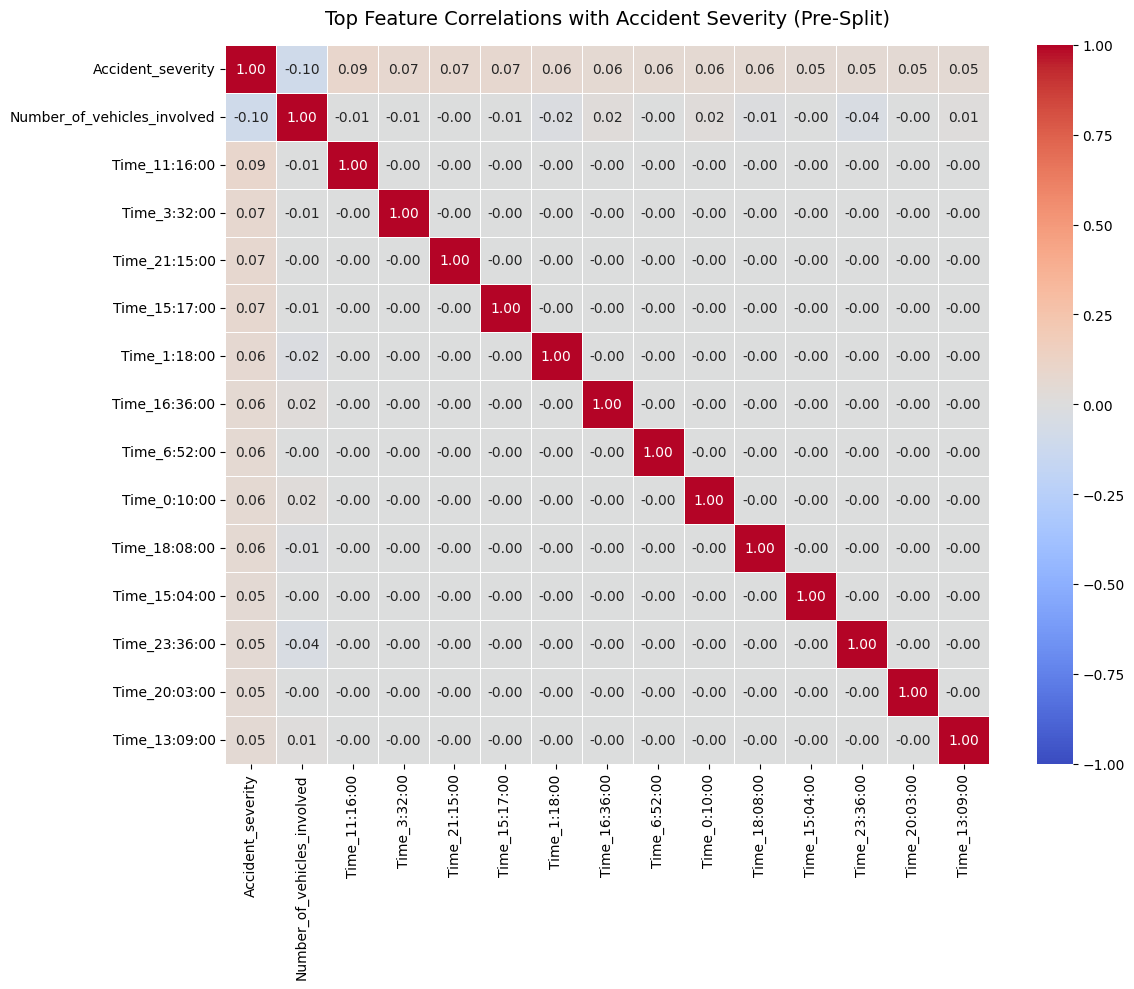

In [31]:
#Correlation Heatmap
explore_df = X.copy()
explore_df['Accident_severity'] = y

top_correlations = explore_df.corr()['Accident_severity'].abs().nlargest(15).index
corr_matrix = explore_df[top_correlations].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True,fmt='.2f',cmap='coolwarm',vmin=-1, vmax=1,linewidths=0.5)

plt.title('Top Feature Correlations with Accident Severity (Pre-Split)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [32]:
#Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nSuccess! Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"\nCreated {X.shape[1]} total numerical features after One-Hot Encoding!")


Success! Training features shape: (9852, 1253)
Testing features shape: (2464, 1253)

Created 1253 total numerical features after One-Hot Encoding!


In [33]:
#Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

balanced_rf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

print("Training the balanced model...")
balanced_rf.fit(X_train, y_train)
y_pred_balanced = balanced_rf.predict(X_test)

print("\n--- Balanced Model Evaluation ---")
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_balanced):.2f}\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred_balanced, target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))

Training the balanced model...

--- Balanced Model Evaluation ---
Overall Accuracy Score: 0.85

Detailed Performance Report:
              precision    recall  f1-score   support

      Slight       0.85      1.00      0.92      2084
     Serious       0.00      0.00      0.00       349
       Fatal       0.00      0.00      0.00        31

    accuracy                           0.85      2464
   macro avg       0.28      0.33      0.31      2464
weighted avg       0.72      0.85      0.78      2464



In [34]:
#Logistic_Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, solver='liblinear')

print("Training the balanced Logistic Regression model...")
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n--- Logistic Regression Model Evaluation ---")
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_lr):.2f}\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))

Training the balanced Logistic Regression model...

--- Logistic Regression Model Evaluation ---
Overall Accuracy Score: 0.82

Detailed Performance Report:
              precision    recall  f1-score   support

      Slight       0.88      0.92      0.90      2084
     Serious       0.42      0.24      0.31       349
       Fatal       0.18      0.42      0.25        31

    accuracy                           0.82      2464
   macro avg       0.49      0.53      0.48      2464
weighted avg       0.80      0.82      0.81      2464



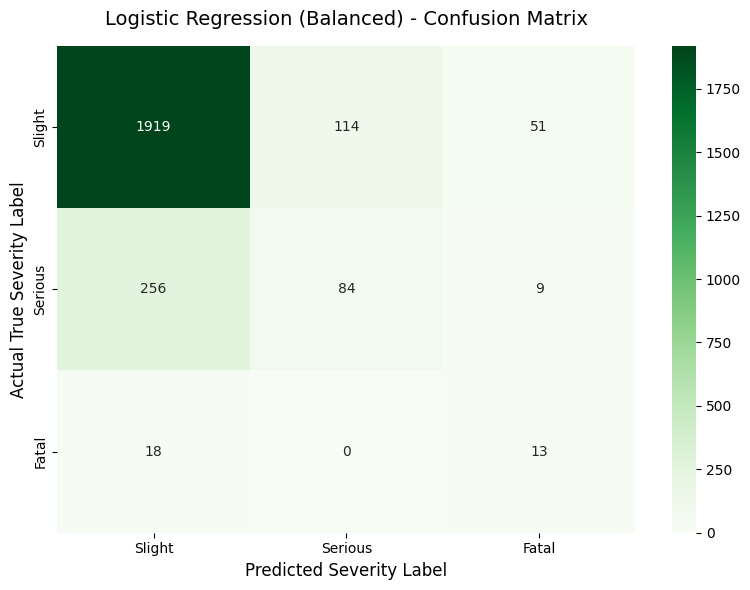

In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm= confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True, fmt='d', cmap='Greens', xticklabels=['Slight', 'Serious', 'Fatal'], yticklabels=['Slight', 'Serious', 'Fatal'])

plt.title('Logistic Regression (Balanced) - Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Severity Label', fontsize=12)
plt.ylabel('Actual True Severity Label', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
#Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

print("Training the balanced Decision Tree model...")
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n--- Decision Tree Model Evaluation ---")
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred_dt):.2f}\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Slight', 'Serious', 'Fatal'], zero_division=0))

Training the balanced Decision Tree model...

--- Decision Tree Model Evaluation ---
Overall Accuracy Score: 0.74

Detailed Performance Report:
              precision    recall  f1-score   support

      Slight       0.87      0.83      0.85      2084
     Serious       0.26      0.24      0.25       349
       Fatal       0.09      0.48      0.15        31

    accuracy                           0.74      2464
   macro avg       0.41      0.52      0.42      2464
weighted avg       0.78      0.74      0.76      2464



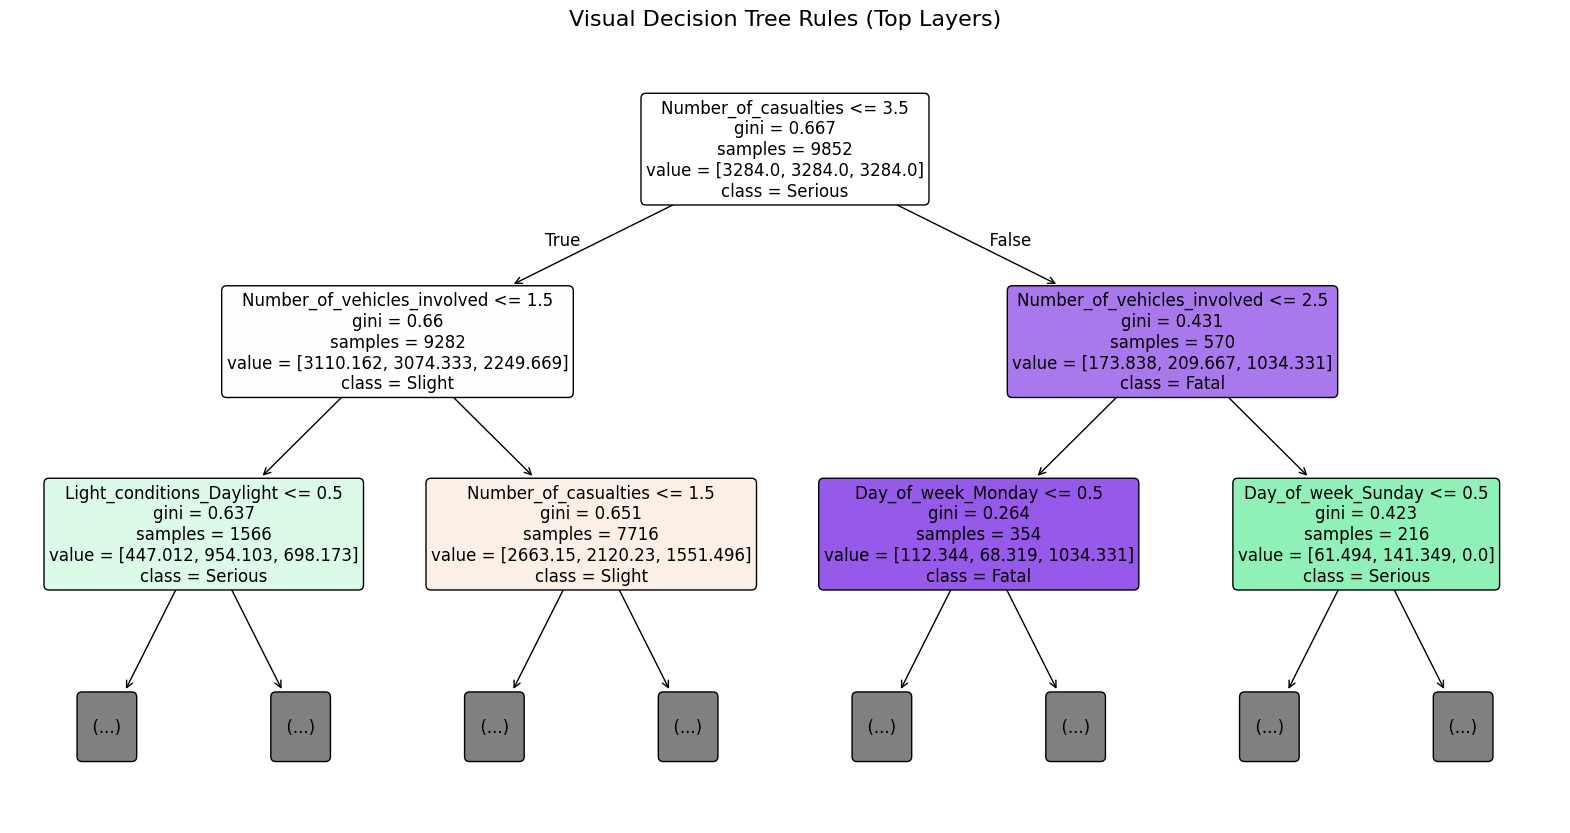

In [37]:
#Visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=2, feature_names=list(X.columns), class_names=['Slight', 'Serious', 'Fatal'], filled=True, rounded=True, fontsize=12)
plt.title("Visual Decision Tree Rules (Top Layers)", fontsize=16, pad=20)
plt.show()

In [40]:
#Prediction
accurate_cases = [
    {
        "Data": {
            'Time': '12:00:00',
            'Day_of_week': 'Monday',
            'Age_band_of_driver': '31-50',
            'Sex_of_driver': 'Male',
            'Educational_level': 'high school',
            'Vehicle_driver_relation': 'owner',
            'Driving_experience': 'above 10yr',
            'Type_of_vehicle': 'automobile',
            'Owner_of_vehicle': 'owner',
            'Service_year_of_vehicle': '5-10yr',
            'Defect_of_vehicle': 'no defect',
            'Area_accident_occured': 'residential areas',
            'Lanes_or_Medians': 'two-way (divided)',
            'Road_allignment': 'tangent road with flat terrain',
            'Types_of_Junction': 'no junction',
            'Road_surface_type': 'asphalt roads',
            'Type_of_collision': 'rear-end',
            'Vehicle_movement': 'going straight',
            'Casualty_class': 'Unknown',
            'Sex_of_casualty': 'Unknown',
            'Age_band_of_casualty': 'Unknown',
            'Casualty_severity': 'Unknown',
            'Work_of_casuality': 'driver',
            'Fitness_of_casuality': 'normal',
            'Pedestrian_movement': 'not a pedestrian',
            'Cause_of_accident': 'no distancing',
            'Light_conditions': 'daylight',
            'Weather_conditions': 'normal',
            'Number_of_vehicles_involved': 2,
            'Number_of_casualties_involved': 1
        }
    }
]

for case in accurate_cases:
    case_df = pd.DataFrame([case["Data"]])

    for col in case_df.select_dtypes(include=['object']).columns:
        case_df[col] = case_df[col].astype(str).str.strip().str.lower()

    inverse_mapping = {0: 'Slight Injury 🟢', 1: 'Serious Injury 🟡', 2: 'Fatal Injury 🔴'}
    case_encoded = pd.get_dummies(case_df)

    case_aligned = case_encoded.reindex(columns=X_train.columns, fill_value=0)

    numeric_prediction = dt_model.predict(case_aligned)[0]
    string_prediction = inverse_mapping[numeric_prediction]

    print(f"Predicted Severity with complete data: {string_prediction}")

Predicted Severity with complete data: Slight Injury 🟢
